# Course Curriculum Design with Machine Learning and ChatGPT

Please use your own OpenAI key to activate OpenAI's API:

In [ ]:
user_key = ""

## 1. Objective:

Data science, analytics, AI, and big data are becoming widely used across many fields, leading to an ever-increasing demand for data analysts, data scientists, ML engineers, analytics managers, and other data professionals. As a result, data science education has become an increasingly important topic for educators and entrepreneurs. In this project, we design a curriculum for a new “Master of Business and Management in Data Science and Artificial Intelligence” program at the University of Toronto, with a focus on both technical and business/soft skills. The curriculum contains a set of courses (and the topics covered in each course) that provide students with the technical and business skills needed to pursue careers as data scientists, analytics and data managers, data analysts, business analysts, AI system designers, and related professionals. We extract skills that are in demand at the job market from job vacancies posted on http://indeed.com web-portal and apply clustering algorithms to group/segment skills into courses.

A sample Python code was used to web-scrape job postings from http://indeed.com web-portal, which was further modified for this project. Scraping was performed for “Data Scientist” and “Manager of Analytics” positions for location code “CA”. The resulting dataset contains at least 1,000 unique job postings. We experiment with different Natural Language Processing (NLP) algorithms to extract skills (features) from the web-scraped job postings. We manually define a list of keywords/key phrases (N-grams) that represent skills, e.g., “Python”, “R”, “deep learning”, “problem solving”, “communications”, “teamwork”, or use pre-trained NLP algorithms, such as ChatGPT, to automatically extract skills/features from the dataset.

Finally, we use the skills extracted from job postings as features and apply two clustering algorithms to create clusters of skills that can be interpreted as courses. The first clustering algorithm we use is a **hierarchical clustering algorithm with one feature**, where the feature represents the distance between each pair of skills. The idea is that if a pair of skills appears together in many job postings, those two skills are likely to be required together in a job, making it reasonable to teach those skills (topics) within the same course (cluster). Based on this idea, we define the distance measure, create a dendrogram, and interpret each cluster as a course. For the second clustering algorithm, we choose between **k-means** and **DBSCAN**. we use **at least 10 features** as inputs for the second clustering algorithms. Similar to the first approach, we interpret each resulting cluster as a course.

Based on the first and second clustering analyses separately, we create a sequence of **8-12 courses**. For each course, we include **3-8 topics (based on skills)** that should be covered in the course. We list the courses in a logical order, where a course that requires another course as a prerequisite is placed after the prerequisite course. We use our own judgment to determine the logical sequence of courses or interpret the clustering results to guide the course organization. Finally, we combine the two proposed course curricula into a single curriculum that we recommend for the master program.

Import the needed libraries:

In [ ]:
from google.colab import files
import os
import sys
import shutil
from pathlib import Path
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline
from wordcloud import WordCloud
from matplotlib.gridspec import GridSpec
try:
    from rich.console import Console
except:
    !pip install rich
    from rich.console import Console

In [ ]:
import re
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download("wordnet")
nltk.download("omw-1.4")
try:
    import contractions
except:
    !pip install contractions
    import contractions

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00


In [ ]:
try:
    import openai
except:
    !pip install openai
    import openai
openai.api_key = user_key

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
import scipy.cluster.hierarchy as sch
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import normalize, MinMaxScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA

## 2. Data cleaning:

Two Python code samples for web-scraping job postings from the http://indeed.com web portal were provided in this project: `Indeed_webscraping.ipynb` and `Improved_webscraping-CH.ipynb`. Both notebooks were tested on a Win64 platform. `Indeed_webscraping.ipynb` was run on both Chrome and Firefox without any problems. However, the "Unable to locate element: #jobDescriptionText" error was encountered when running `Improved_webscraping-CH.ipynb`. This error was fixed by adding a random time delay between loading the web page and executing the CSS selector to allow the job description section to fully load. This technique is often referred to as "rate limiting" or "throttling" and is a common practice in web scraping and other types of programs that interact with web servers.

Other modifications to the original notebook included adding two lists as placeholders for positions and locations. A for loop was added to iterate over different combinations of job positions and locations. In every iteration, the obtained dataframe was appended to the dataframe containing all values. Scraping was performed for data scientist and manager of analytics positions for location code CA. This ensures that we are targeting not only technical skills, but also soft skills.

It is worth noting that we could not scrape a sufficient number of job postings in a reasonable amount of time using Canada as the location. Therefore, we opted for using the location code CA, which encompasses both Canada and California in the United States. This provides us with a dataset containing job postings from both countries, allowing for a more diverse and representative sample.

In [ ]:
def clean_text_data(text):
    """
    Rremoves various types of unwanted information, including hashtags, HTML tags, URLs, etc.
    """

    # Remove hashtags:
    text = re.sub("#[\w]*","", text)

    # Remove twitter Return handles:
    text = re.sub("RT @[\w]*:","", text)

    # Remove user tags:
    text = re.sub("@[\w]*","", text)

    # Remove HTML tags:
    text = BeautifulSoup(text, "html.parser").get_text()

    # Remove links:
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www.\S+", "", text)

    # Remove escape characters:
    text = re.sub(r"\r+|\n+|\t+", " ", text)

    # Lowercase the letters:
    text = text.lower()

    # Fix contractions:
    text = contractions.fix(text)

    # Remove punctuations:
    text = re.sub('[()!?]', ' ', text)
    text = re.sub('\[.*?\]',' ', text)

    # Filter non-letters:
    text = re.sub("[^a-zA-Z]", " ", text)

    # Tokenize to words:
    token = nltk.word_tokenize(text)

    # Remove stopwords:
    sw = stopwords.words('english') + ['would', 'could']

    # Lemmatize:
    wn = nltk.stem.WordNetLemmatizer()
    text = [wn.lemmatize(w) for w in token if w not in sw]

    # Rejoin the words:
    return " ".join(text)

<>:7: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:13: SyntaxWarning: invalid escape sequence '\w'
<>:33: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:13: SyntaxWarning: invalid escape sequence '\w'
<>:33: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_578/3668593614.py:7: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub("#[\w]*","", text)
/tmp/ipykernel_578/3668593614.py:10: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub("RT @[\w]*:","", text)
/tmp/ipykernel_578/3668593614.py:13: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub("@[\w]*","", text)
/tmp/ipykernel_578/3668593614.py:33: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]',' ', text)


In [ ]:
def get_avg_yearly_salary(salary_str):
    """
    Extracts salary limits and returns the average salary as an annual value.
    """
    if pd.isna(salary_str):
        return np.nan

    # Replace the Unicode minus sign with a regular hyphen:
    salary_str = salary_str.replace("−", "-")
    pattern = r'[\d,]+\.?\d*'
    matches = re.findall(pattern, salary_str)
    numbers = [float(m.replace(',', '')) for m in matches]
    if len(numbers) == 0:
        return np.nan

    avg_salary = np.mean(numbers)

    if "month" in salary_str:
        avg_salary = avg_salary * 12

    if "hour" in salary_str:
        # Assuming 8-hour workdays and 250 working days in a year:
        avg_salary = avg_salary * 8 * 250

    return avg_salary

In [ ]:
def get_date(date_str):
    """
    Extracts date of posting.
    """
    pattern = r'\d+'

    # Find all occurrences of the pattern in the string:
    matches = re.findall(pattern, date_str)

    # If at least one match is found, return the first one as a float:
    if matches:
        return float(matches[0])

    # If no matches are found, return None:
    else:
        return np.nan

Next, we will apply the `clean_data`, `get_avg_yearly_salary`, and `get_date` functions to the dataframe to ensure it is ready for analysis. After cleaning, we need to check for any null values in the 'Descriptions' columns. Since we already know that there are only few missing values, we can simply drop those rows.

Load the project files:

In [ ]:
!git clone https://github.com/ali-sh-96/Machine-learning-Portfolio.git

# Get the path to the installed package.
root_dir = Path("Machine-learning-Portfolio")

# Select project
project_name = "project4"
project_dir = root_dir / project_name

Cloning into 'Machine-learning-Portfolio'...
remote: Enumerating objects: 171, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 171 (delta 78), reused 101 (delta 42), pack-reused 32 (from 1)
Receiving objects: 100% (171/171), 82.86 MiB | 17.51 MiB/s, done.
Resolving deltas: 100% (84/84), done.
Updating files: 100% (29/29), done.


Importing the data:

In [ ]:
# Load dataframe:
df = pd.read_csv(project_dir / "webscraping_results_project4.csv", low_memory=False, keep_default_na=False, na_values=[''])

# Drop duplicate rows:
df = df.drop_duplicates(keep=False)

# Keep relevant columns:
df = df.drop(["Description", "Links"], axis=1)

# Clean 'Descriptions', 'Salary', and 'Date' columns:
df["Descriptions"] = df["Descriptions"].apply(clean_text_data)
df["Salary"] = df["Salary"].apply(get_avg_yearly_salary)
df["Date"] = df["Date"].apply(get_date)

# Replace empty strings with nan values:
df["Descriptions"] = df["Descriptions"].replace("", np.nan)
idx = df[df["Descriptions"].isna()].index
print("Null values in 'Descriptions' column:", len(idx))
df = df.drop(idx).reset_index(drop=True)

# Show cleaned dataframe:
print(f"Dataframe shape: {df.shape}")
df.head()

Null values in 'Descriptions' column: 0
Dataframe shape: (1061, 7)


,Title,Company,Location,Rating,Date,Salary,Descriptions
0,Data Scientist,Great American Insurance Company,"Remote in Los Angeles, CA 90017",3.8,6.0,103500.0,great working leader insurance industry mean o...
1,Data Scientist,ironSource,"Remote in San Francisco, CA 94107",NaN,30.0,147500.0,gather analyze large set structured unstructur...
2,Sr. Data Scientist,Adobe,"San Francisco, CA 94103 (South Of Market area)",4.3,14.0,172700.0,company changing world digital experience adob...
3,Data Scientist,Spindl,"Remote in San Francisco, CA",NaN,7.0,NaN,founding data scientist well funded company lo...
4,Educational Data Scientist,Expatiate Communications,"Pasadena, CA 91101 (Pasadena area)",3.6,4.0,125000.0,ai education expatiate communication aim devel...


The cleaned dataframe has 1061 > 1000 unique job titles.

## 3. Feature engineering:

Here, we engineer features for clustering analysis:
- We define skills manually based on our own knowledge and by using ChatGPT. We use OpenAI's API to access the ChatGPT (gpt-3.5-turbo) model and request a list of skills for use in the extraction process. For our analysis, we combine the manually generated skills with those generated by ChatGPT.
- We extract skills using N-grams or pre-trained NLP algorithms.

We also visualize key information by generating at least two visual representations of the extracted information (e.g., count of each skill by job title or company name, average salary by skill, etc.).

### Manual feature extraction:

To identify the key features for clustering algorithm, we can create lists of keywords that represent technical and soft skills. By computing the frequency of these keywords in the job descriptions, we can determine which features are most important. This approach can help us gain insight into the essential skills required for the jobs and aid in the analysis of job requirements.

In [ ]:
technical_keywords = [
    "Artificial intelligence", "Azure", "Big data", "Computer science",
    "Hadoop", "High performance computing", "Internet of things", "Java",
    "Machine learning", "Mathematics", "Modeling",
    "Natural language processing", "Optimization", "Power BI", "Prediction",
    "Python", "R", "SAS", "Software development", "SQL", "Tableau"
]

soft_keywords = [
    "Collaboration", "Communication", "Consulting", "Creativity", "Energetic",
    "Finance", "Hardworking", "Inquisitive", "Leadership", "Marketing",
    "Multitasking", "Negotiation", "Passion", "Positive", "Project management",
    "Presentation", "Problem-solving", "Teamwork", "Adaptability",
    "Critical thinking"
]

equivalent_keywords = {
    "AI": "Artificial intelligence",
    "HPC": "High performance computing",
    "IOT": "Internet of things",
    "ML": "Machine learning",
    "NLP": "Natural language processing"
}

In [ ]:
frequency_dict = {}

# Loop through each keyword and count its frequency of appearance in the 'Descriptions' column:
for keyword in technical_keywords + soft_keywords + list(equivalent_keywords.values()):
    # Use the common name for equivalent keywords
    common_name = equivalent_keywords.get(keyword, keyword)

    # If this is the first time the common name is encountered, initialize its count to 0:
    if common_name not in frequency_dict:
        frequency_dict[common_name] = 0

    # Count the appearances of the keyword in the 'Descriptions' column and add it to the common name's count:
    count = df["Descriptions"].str.contains(f'(?i)\\b{keyword}\\b', regex=True, case=False).sum()

    frequency_dict[common_name] += count

In [ ]:
# Create empty dictionaries to store the counts for technical and soft skills:
technical_counts = {}
soft_counts = {}

# Loop through the technical and soft skills and their equivalent keywords, and add up their counts:
for keyword in technical_keywords:
    if keyword in equivalent_keywords:
        continue
    count = frequency_dict.get(keyword)
    # check if count is not None:
    if count is not None:
        technical_counts[keyword] = count

for keyword in soft_keywords:
    if keyword in equivalent_keywords:
        continue
    count = frequency_dict.get(keyword)
    # check if count is not None:
    if count is not None:
        soft_counts[keyword] = count

# Sort the frequency dictionary in descending order:
technical_counts = dict(sorted(technical_counts.items(), key=lambda x: x[1], reverse=True))
soft_counts = dict(sorted(soft_counts.items(), key=lambda x: x[1], reverse=True))

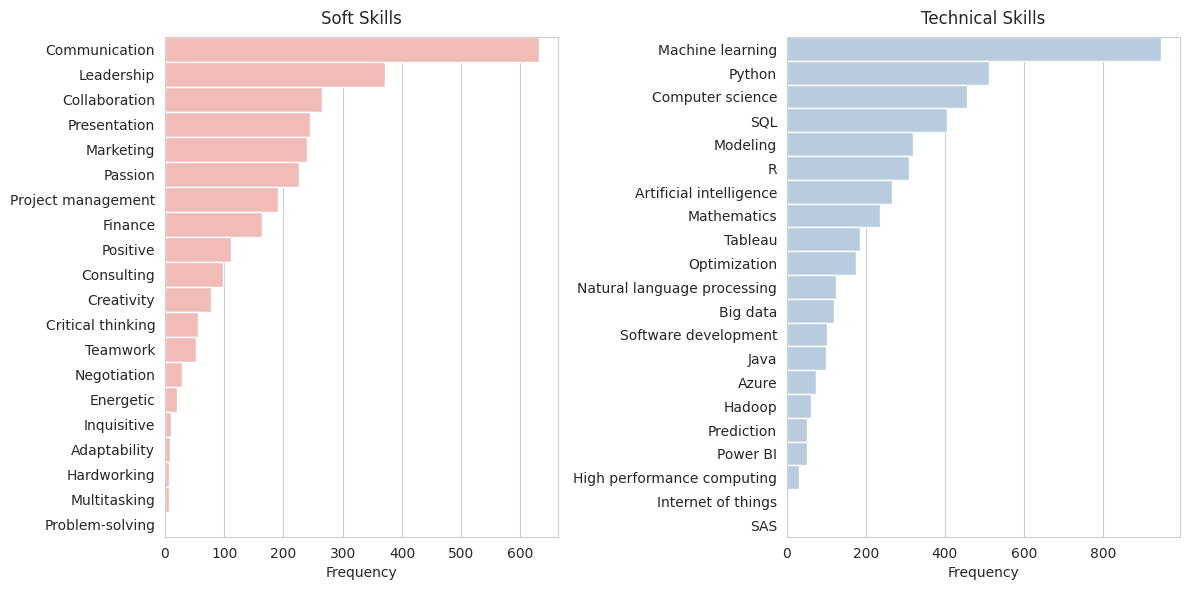

In [ ]:
# Generate the color palette:
palette = sns.color_palette('Pastel1')

# Plot the frequency counts for soft and technical skills side by side:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

# Plot the soft skills:
sns.barplot(x=list(soft_counts.values()), y=list(soft_counts.keys()), ax=ax1, color=palette[0], width=1)
ax1.set_xlabel('Frequency')
ax1.set_title('Soft Skills', y=1.01)

# Plot the technical skills:
sns.barplot(x=list(technical_counts.values()), y=list(technical_counts.keys()), ax=ax2, color=palette[1], width=1)
ax2.set_xlabel('Frequency')
ax2.set_title('Technical Skills', y=1.01)

plt.tight_layout()
plt.show()

### GPT-3.5-Turbo:

Alternatively, we can use the GPT-3.5-Turbo model to generate two lists of keywords related to technical and soft skills. We can then perform the same analysis as in the previous step by counting the frequency of appearance of each keyword to identify the important features. This approach may be useful if we want to expand our list of skills or if we are dealing with a large dataset where manually identifying relevant keywords may not be feasible.

In [ ]:
# Get two lists of keywords for technical and soft skills:
num_skills = 20

try:
    # Technical skills:
    skills_list = []
    prompt = f"""
    Please provide a list of {num_skills} keywords for technical skills required for data scientists and managers of analytics.
    For each skill, please provide a brief keyword that summarizes it.
    Here is the format for your final results:
    '\n1. \n2. ... \n20. '
    """

    response = openai.Completion.create(
        engine="text-davinci-002",
        prompt=prompt,
        max_tokens=1024,
        n=1,
        stop=None,
        temperature=0.5,
    )

    response_text = response.choices[0].text.strip()
    skills_list = response_text.split(",")

    # Use regular expressions to create a list:
    technical_skills_list = [re.sub(r'\d+\.\s+', '', skill.strip()) for skill in skills_list[0].split('\n') if skill]

    # Soft skills:
    skills_list = []
    prompt = f"""
    Please provide a list of {num_skills} keywords for soft skills required for data scientists and managers of analytics.
    For each skill, please provide a brief keyword that summarizes it.
    Here is the format for your final results:
    '\n1. \n2. ... \n20. '
    """

    response = openai.Completion.create(
        engine="text-davinci-002",
        prompt=prompt,
        max_tokens=1024,
        n=1,
        stop=None,
        temperature=0.5,
    )

    response_text = response.choices[0].text.strip()
    skills_list = response_text.split(",")

    # Use regular expressions to create a list:
    soft_skills_list = [re.sub(r'\d+\.\s+', '', skill.strip()) for skill in skills_list[0].split('\n') if skill]
except:
    # If OpenAI key is not provided, continue using initial keywords:
    technical_skills_list = technical_keywords
    soft_skills_list = soft_keywords

In [ ]:
technical_counts = {}
soft_counts = {}

# Loop through each keyword and count its frequency of appearance in the 'Descriptions' column:
for keyword in technical_skills_list:
    # Count the appearances of the keyword in the 'Descriptions' column and add it to the common name's count:
    count = df["Descriptions"].str.contains(f'(?i)\\b{keyword}\\b', regex=True, case=False).sum()
    # check if count is not zero:
    if count != 0:
        technical_counts[keyword] = count

# Loop through each keyword and count its frequency of appearance in the 'Descriptions' column:
for keyword in soft_skills_list:
    # Count the appearances of the keyword in the 'Descriptions' column and add it to the common name's count:
    count = df["Descriptions"].str.contains(f'(?i)\\b{keyword}\\b', regex=True, case=False).sum()
    # check if count is not zero:
    if count != 0:
        soft_counts[keyword] = count

# Sort the frequency dictionary in descending order:
technical_counts = dict(sorted(technical_counts.items(), key=lambda x: x[1], reverse=True))
soft_counts = dict(sorted(soft_counts.items(), key=lambda x: x[1], reverse=True))

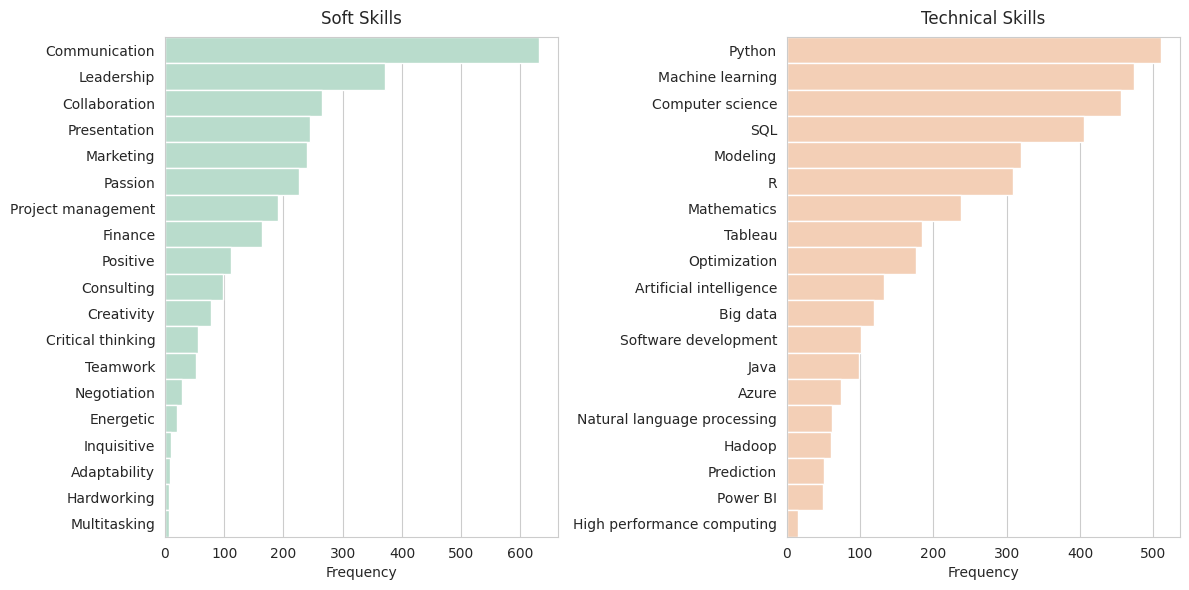

In [ ]:
# Generate the color palette:
palette = sns.color_palette('Pastel2')

# Plot the frequency counts for soft and technical skills side by side:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

# Plot the soft skills:
sns.barplot(x=list(soft_counts.values()), y=list(soft_counts.keys()), ax=ax1, color=palette[0], width=1)
ax1.set_xlabel('Frequency')
ax1.set_title('Soft Skills', y=1.01)

# Plot the technical skills:
sns.barplot(x=list(technical_counts.values()), y=list(technical_counts.keys()), ax=ax2, color=palette[1], width=1)
ax2.set_xlabel('Frequency')
ax2.set_title('Technical Skills', y=1.01)

plt.tight_layout()
plt.show()

### N-grams:

To extract relevant skills from job descriptions, we cannot rely solely on N-gram algorithms, as they may generate many irrelevant words. Instead, we need to experiment with different N-gram combinations, such as unigrams and bigrams, to identify the most meaningful features. Moreover, we may also need to manually differentiate technical and soft skills, which can be time-consuming and challenging. Alternatively, we could leverage language models such as Chat-GPT to automatically identify and extract relevant skills from text data.

In [ ]:
# Create a CountVectorizer object:
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')

# Fit and transform the 'Descriptions' column to create a sparse matrix of n-gram counts:
X = vectorizer.fit_transform(df["Descriptions"])

# Create a list of n-grams (skills) and their corresponding counts:
ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).tolist()[0]

# Create a DataFrame of skills and their counts:
skills_df = pd.DataFrame(list(zip(ngrams, counts)), columns=["skill", "count"])

# Sort the DataFrame in descending order by count and reset the index:
skills_df = skills_df.sort_values(by="count", ascending=False).reset_index(drop=True)

# Add the rank column:
skills_df["rank"] = skills_df.index + 1

# Print the top 50 skills and their counts as two side-by-side markdown tables:
table1 = skills_df.iloc[0:50].to_markdown(index=False, tablefmt='fancy_grid')
table2 = skills_df.iloc[50:100].to_markdown(index=False, tablefmt='fancy_grid')

# Split the tables into separate lines:
lines1 = table1.splitlines()
lines2 = table2.splitlines()

# Print the lines side-by-side:
for line1, line2 in zip(lines1, lines2):
    print(line1.ljust(60), line2)

╒══════════════════════════╤═════════╤════════╕              ╒══════════════════════════╤═════════╤════════╕
│ skill                    │   count │   rank │              │ skill                    │   count │   rank │
╞══════════════════════════╪═════════╪════════╡              ╞══════════════════════════╪═════════╪════════╡
│ machine learning         │    1447 │      1 │              │ equal employment         │     216 │     51 │
├──────────────────────────┼─────────┼────────┤              ├──────────────────────────┼─────────┼────────┤
│ data science             │     893 │      2 │              │ artificial intelligence  │     214 │     52 │
├──────────────────────────┼─────────┼────────┤              ├──────────────────────────┼─────────┼────────┤
│ year experience          │     712 │      3 │              │ data management          │     214 │     53 │
├──────────────────────────┼─────────┼────────┤              ├──────────────────────────┼─────────┼────────┤
│ data scientist   

From the job requirements list, we can identify several important features. It's worth noting that not all important job requirements are skills. For instance, "years of experience" or "work experience" may be essential for a particular job but do not qualify as skills. Hence, when performing skill extraction, it is crucial to differentiate between skills and other aspects of a job description.

In [ ]:
technical_keywords = [
    "Machine learning", "Data analytics", "Deep learning",
    "Artificial intelligence", "Data management", "Data visualization",
    "Computer vision", "Statistical analysis", "Big data"
]

soft_keywords = [
    "Communication", "Project management", "Problem solving", "Decision making"
]

In our exploration, we also tested the use of unigrams for N-gram analysis. However, this approach did not yield significant results as many unigrams were not relevant to skills. Additionally, generating a table with 500 rows and manually identifying relevant features proved to be inefficient.

To address this, we considered defining a set of keywords to extract skills using N-grams or an NLP algorithm like the one available in the `nltk` module. However, these methods did not offer any significant advantages over the manual extraction approach, as they still relied on defining an effective set of keywords.

In the end, we determined the final set of skills for feature engineering by considering all three methods: manual extraction, Chat GPT, and N-grams.

In [ ]:
technical_skills = [
    "Artificial intelligence", "Azure", "Big data", "Computer science",
    "Data analysis", "Data analytics", "Data management", "Data mining",
    "Deep learning", "Java", "Machine learning", "Modeling", "Optimization",
    "Python", "R", "Software development", "SQL", "Spark",
    "Statistical analysis", "Tableau"
]

soft_skills = [
    "Collaboration", "Communication", "Consulting", "Creativity",
    "Critical thinking", "Decision making", "Finance", "Leadership",
    "Marketing", "Negotiation", "Organization", "Passion", "Positive",
    "Presentation", "Problem solving", "Project management", "Teamwork",
    "Writing", "Coaching", "Mentoring"
]

In [ ]:
print("Number of engineered technical skills: {}".format(len(technical_skills)))
print("Number of engineered soft skills: {}".format(len(soft_skills)))

Number of engineered technical skills: 20
Number of engineered soft skills: 20


In [ ]:
technical_counts = {}
soft_counts = {}

# Loop through each keyword and count its frequency of appearance in the 'Descriptions' column:
for keyword in technical_skills:
    # Count the appearances of the keyword in the 'Descriptions' column and add it to the common name's count:
    count = df["Descriptions"].str.contains(f'(?i)\\b{keyword}\\b', regex=True, case=False).sum()
    # check if count is not zero:
    if count != 0:
        technical_counts[keyword] = count

# Loop through each keyword and count its frequency of appearance in the 'Descriptions' column:
for keyword in soft_skills:
    # Count the appearances of the keyword in the 'Descriptions' column and add it to the common name's count:
    count = df["Descriptions"].str.contains(f'(?i)\\b{keyword}\\b', regex=True, case=False).sum()
    # check if count is not zero:
    if count != 0:
        soft_counts[keyword] = count

# Sort the frequency dictionary in descending order:
technical_counts = dict(sorted(technical_counts.items(), key=lambda x: x[1], reverse=True))
soft_counts = dict(sorted(soft_counts.items(), key=lambda x: x[1], reverse=True))

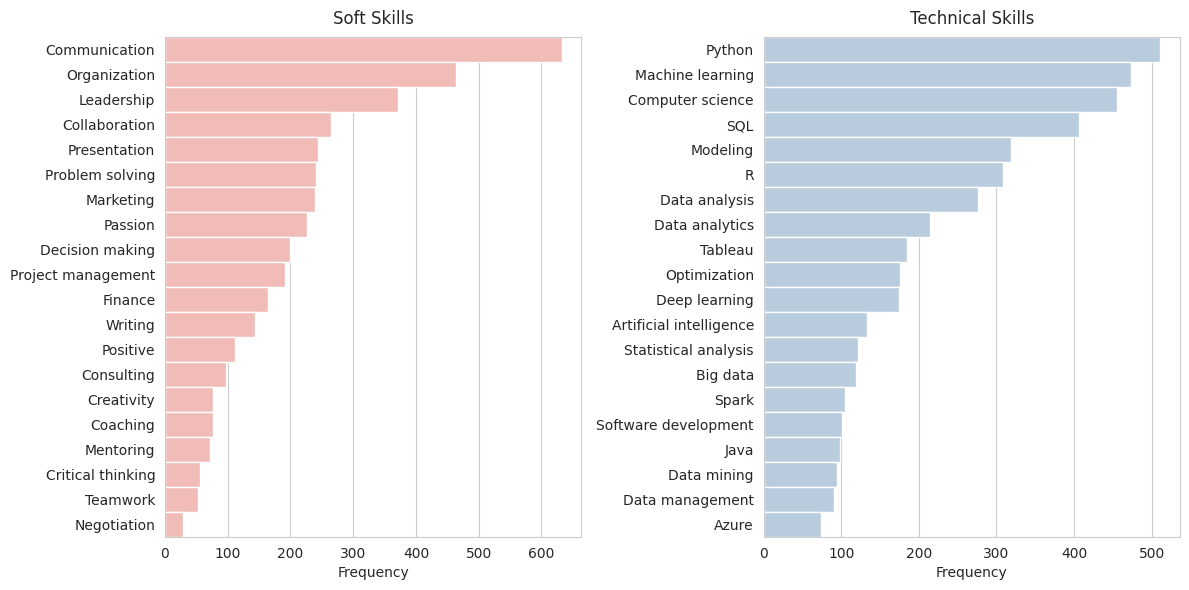

In [ ]:
# Generate the color palette:
palette = sns.color_palette('Pastel1')

# Plot the frequency counts for soft and technical skills side by side:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

# Plot the soft skills:
sns.barplot(x=list(soft_counts.values()), y=list(soft_counts.keys()), ax=ax1, color=palette[0], width=1)
ax1.set_xlabel('Frequency')
ax1.set_title('Soft Skills', y=1.01)

# Plot the technical skills:
sns.barplot(x=list(technical_counts.values()), y=list(technical_counts.keys()), ax=ax2, color=palette[1], width=1)
ax2.set_xlabel('Frequency')
ax2.set_title('Technical Skills', y=1.01)

plt.tight_layout()
plt.show()

## 4. Exploratory data analysis:

This section aims to present the most critical information in a visual format. To achieve this goal, we have included four plots: barplot depicting the average salary, barplot showing the count of skills in job categories, pie chart representing the distribution of technical and soft skills in job categories, word clouds for a quick overview. Please note that the 'Salary' column in the dataframe has been cleaned and contains average annual salary values for each job posting.

In [ ]:
print("Number of NaN values in 'Salary' column: {}".format(df['Salary'].isna().sum()))

Number of NaN values in 'Salary' column: 384


### Average salary of skills:

The bar charts provided below illustrate the skills that are associated with job postings with higher salaries. Upon analysis, it can be observed that deep learning, Spark, and machine learning are the top three technical skills that are associated with higher salaries. Additionally, Java is the programming language that is associated with the highest salary. Regarding soft skills, creativity was the skill with the highest salary. It is interesting to note that creativity, which is not necessarily associated with technical expertise, has a significant impact on salaries.

In [ ]:
# Create separate dataframes for technical and soft skills:
df_skills_tech = df.dropna(subset=["Salary"]).copy()
df_skills_tech['Skills'] = df_skills_tech['Descriptions'].apply(
    lambda x:[skill for skill in technical_skills if skill.lower() in x.lower()])
df_skills_tech = df_skills_tech.explode('Skills')
avg_salary_by_tech_skill = df_skills_tech.groupby('Skills')['Salary'].mean().sort_values(ascending=False)

df_skills_soft = df.dropna(subset=["Salary"]).copy()
df_skills_soft['Skills'] = df_skills_soft['Descriptions'].apply(
    lambda x: [skill for skill in soft_skills if skill.lower() in x.lower()])
df_skills_soft = df_skills_soft.explode('Skills')
avg_salary_by_soft_skill = df_skills_soft.groupby('Skills')['Salary'].mean().sort_values(ascending=False)

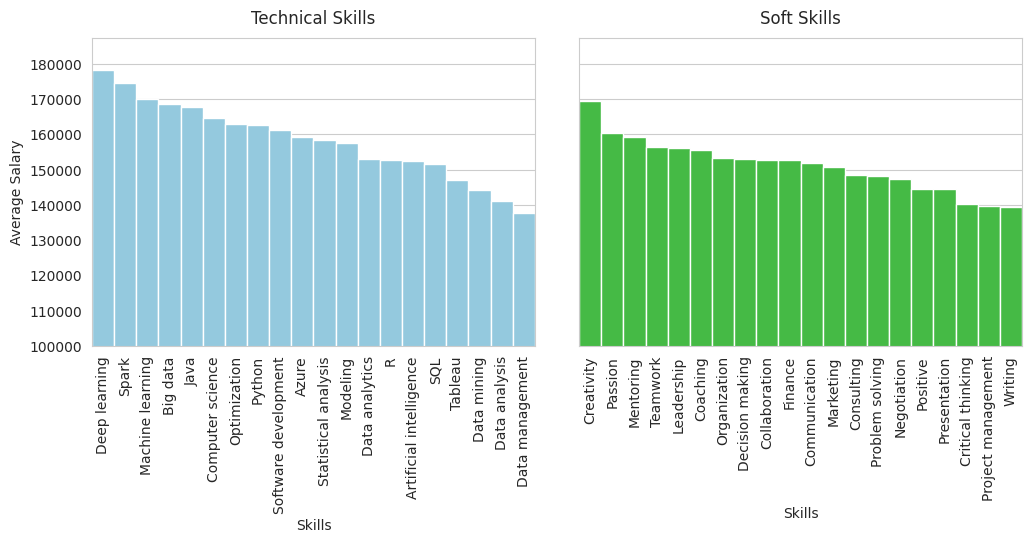

In [ ]:
# Create subplots:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axs[0].set_title('Technical Skills', y=1.02)
axs[1].set_title('Soft Skills', y=1.02)
sns.barplot(x=avg_salary_by_tech_skill.index, y=avg_salary_by_tech_skill.values, color='skyblue', ax=axs[0], width=1)
sns.barplot(x=avg_salary_by_soft_skill.index, y=avg_salary_by_soft_skill.values, color='limegreen', ax=axs[1], width=1)

for ax in axs:
    ax.set_xlabel('Skills')
    ax.set_ylabel('Average Salary')
    for label in ax.get_xticklabels():
        label.set_rotation(90)
    # Set the lower limit to 100000:
    ax.set_ylim([100000, ax.get_ylim()[1]])
plt.subplots_adjust(wspace=0.1)
plt.show()

### Count of each skill against job titles:

The job titles in the dataset may consist of multiple words, such as 'Data Scientist', 'Manager', 'Senior', and so on. To classify a job as 'Manager of Analytics', the job title must contain both the words 'Manager' and 'Analytics'. Any other job that does not meet this criterion will be categorized as a 'Data Scientist' role. Please note that within the 'Data Scientist' category, there may be additional levels such as 'Senior' or 'Manager'.

In [ ]:
analytics_manager_mask = (df['Title'].str.contains('Analytics', case=False) &
                          df['Title'].str.contains('Manager|Mng', case=False))
data_scientist_mask = ~analytics_manager_mask

analytics_manager_df = df[analytics_manager_mask]
data_scientist_df = df[data_scientist_mask]

In [ ]:
technical_counts = {}
soft_counts = {}
dataframe = data_scientist_df

# Loop through each keyword and count its frequency of appearance in the 'Descriptions' column:
for keyword in technical_skills:
    # Count the appearances of the keyword in the 'Descriptions' column and add it to the common name's count:
    count = dataframe["Descriptions"].str.contains(f'(?i)\\b{keyword}\\b', regex=True, case=False).sum()
    # check if count is not zero:
    if count != 0:
        technical_counts[keyword] = count

# Loop through each keyword and count its frequency of appearance in the 'Descriptions' column:
for keyword in soft_skills:
    # Count the appearances of the keyword in the 'Descriptions' column and add it to the common name's count:
    count = dataframe["Descriptions"].str.contains(f'(?i)\\b{keyword}\\b', regex=True, case=False).sum()
    # check if count is not zero:
    if count != 0:
        soft_counts[keyword] = count

# Sort the frequency dictionary in descending order:
data_scientist_technical_counts = dict(sorted(technical_counts.items(), key=lambda x: x[1], reverse=True))
data_scientist_soft_counts = dict(sorted(soft_counts.items(), key=lambda x: x[1], reverse=True))

In [ ]:
technical_counts = {}
soft_counts = {}
dataframe = analytics_manager_df

# Loop through each keyword and count its frequency of appearance in the 'Descriptions' column:
for keyword in technical_skills:
    # Count the appearances of the keyword in the 'Descriptions' column and add it to the common name's count:
    count = dataframe["Descriptions"].str.contains(f'(?i)\\b{keyword}\\b', regex=True, case=False).sum()
    # check if count is not zero:
    if count != 0:
        technical_counts[keyword] = count

# Loop through each keyword and count its frequency of appearance in the 'Descriptions' column:
for keyword in soft_skills:
    # Count the appearances of the keyword in the 'Descriptions' column and add it to the common name's count:
    count = dataframe["Descriptions"].str.contains(f'(?i)\\b{keyword}\\b', regex=True, case=False).sum()
    # check if count is not zero:
    if count != 0:
        soft_counts[keyword] = count

# Sort analytics_manager_technical_counts based on data_scientist_technical_counts:
analytics_manager_technical_counts = dict(sorted(technical_counts.items(),
                                                 key=lambda x: data_scientist_technical_counts.get(x[0], 0), reverse=True))

# Sort analytics_manager_soft_counts based on data_scientist_soft_counts:
analytics_manager_soft_counts = dict(sorted(soft_counts.items(),
                                            key=lambda x: data_scientist_soft_counts.get(x[0], 0), reverse=True))

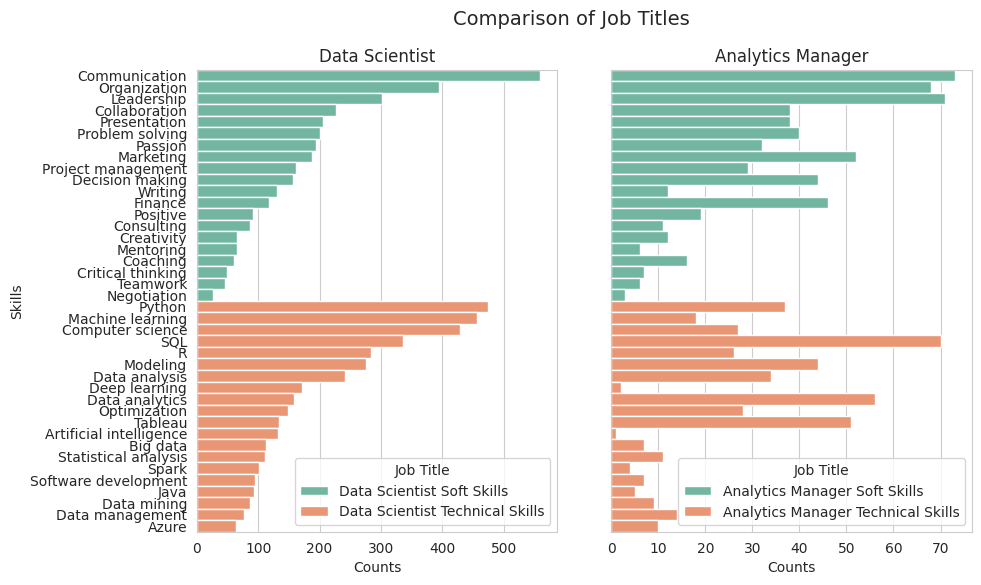

In [ ]:
# Combine the data from the two jobs into a single DataFrame:
df_all = pd.DataFrame({
    'Skills': list(data_scientist_soft_counts.keys()) + list(data_scientist_technical_counts.keys()) + list(analytics_manager_soft_counts.keys()) + list(analytics_manager_technical_counts.keys()),
    'Counts': list(data_scientist_soft_counts.values()) + list(data_scientist_technical_counts.values()) + list(analytics_manager_soft_counts.values()) + list(analytics_manager_technical_counts.values()),
    'Job Title': ['Data Scientist Soft Skills'] * len(data_scientist_soft_counts) + ['Data Scientist Technical Skills'] * len(data_scientist_technical_counts) + ['Analytics Manager Soft Skills'] * len(analytics_manager_soft_counts) + ['Analytics Manager Technical Skills'] * len(analytics_manager_technical_counts)
})

# Create a figure with two subplots:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,6), sharey=True)

# Plot the data using Seaborn barplot with separate colors for each job:
sns.barplot(x='Counts', y='Skills', hue='Job Title', data=df_all[df_all['Job Title'].isin(['Data Scientist Soft Skills', 'Data Scientist Technical Skills'])], ax=ax1, palette='Set2', width=1, dodge=False)
sns.barplot(x='Counts', y='Skills', hue='Job Title', data=df_all[df_all['Job Title'].isin(['Analytics Manager Soft Skills', 'Analytics Manager Technical Skills'])], ax=ax2, palette='Set2', width=1, dodge=False)

# Set titles and labels:
ax1.set_title('Data Scientist')
ax1.set_xlabel('Counts')
ax1.set_ylabel('Skills')
ax1.legend(title='Job Title')

ax2.set_title('Analytics Manager')
ax2.set_xlabel('Counts')
ax2.set_ylabel('Skills')
ax2.legend(title='Job Title')

# Adjust layout and show the plot:
fig.suptitle('Comparison of Job Titles', fontsize=14)
plt.subplots_adjust(wspace=0.15)
plt.show()

Based on the pie charts below, it can be observed that the Analytics Manager role requires more soft skills than technical skills. Soft skills account for 57.5% of the required skills for this role, while technical skills account for the remaining 42.5%. On the other hand, the Data Science role requires more technical skills, with technical skills comprising 54.5% of the total skills required and soft skills account for the remaining 45.5%.

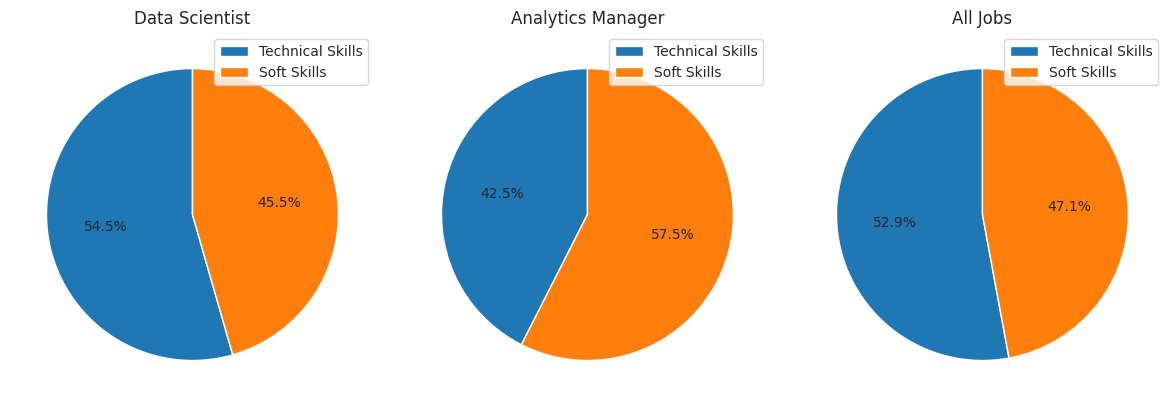

In [ ]:
# Calculate the total counts of hard and soft skills for each job category:
data_scientist_technical_counts_sum = sum(data_scientist_technical_counts.values())
data_scientist_soft_counts_sum = sum(data_scientist_soft_counts.values())
analytics_manager_technical_counts_sum = sum(analytics_manager_technical_counts.values())
analytics_manager_soft_counts_sum = sum(analytics_manager_soft_counts.values())
all_jobs_technical_counts_sum = data_scientist_technical_counts_sum + analytics_manager_technical_counts_sum
all_jobs_soft_counts_sum = data_scientist_soft_counts_sum + analytics_manager_soft_counts_sum

# Create a list of sizes for each pie chart:
sizes_data_scientist = [data_scientist_technical_counts_sum, data_scientist_soft_counts_sum]
sizes_analytics_manager = [analytics_manager_technical_counts_sum, analytics_manager_soft_counts_sum]
sizes_all_jobs = [all_jobs_technical_counts_sum, all_jobs_soft_counts_sum]

# Create a list of colors for each pie chart:
colors = ['darkorange', 'dodgerblue']

# Create a list of labels for the pie charts:
labels = ['Technical Skills', 'Soft Skills']

# Create the subplots and the pie charts:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 4))

sns.set_palette(sns.color_palette(colors))
ax1.pie(sizes_data_scientist, autopct='%1.1f%%', startangle=90)
ax1.set_title('Data Scientist')
ax1.legend(labels, loc='upper right')

sns.set_palette(sns.color_palette(colors))
ax2.pie(sizes_analytics_manager, autopct='%1.1f%%', startangle=90)
ax2.set_title('Analytics Manager')
ax2.legend(labels, loc='upper right')

sns.set_palette(sns.color_palette(colors))
ax3.pie(sizes_all_jobs, autopct='%1.1f%%', startangle=90)
ax3.set_title('All Jobs')
ax3.legend(labels, loc='upper right')

plt.tight_layout()
plt.show()

### Word clouds:

A great technique to visualize the crucial skills for each job category is through word clouds based on skill frequency. We have presented word clouds for both soft and technical skills for two job categories: Data Scientist and Analytics Manager.

In the Analytics Manager role, some unique technical skills include data analytics and Tableau. On the other hand, machine learning and deep learning are skills that are more frequent for the Data Scientist role. Similarly, for soft skills, finance and marketing are frequent skills for the Analytics Manager role, whereas presentation and problem-solving are more important for the Data Scientist role.

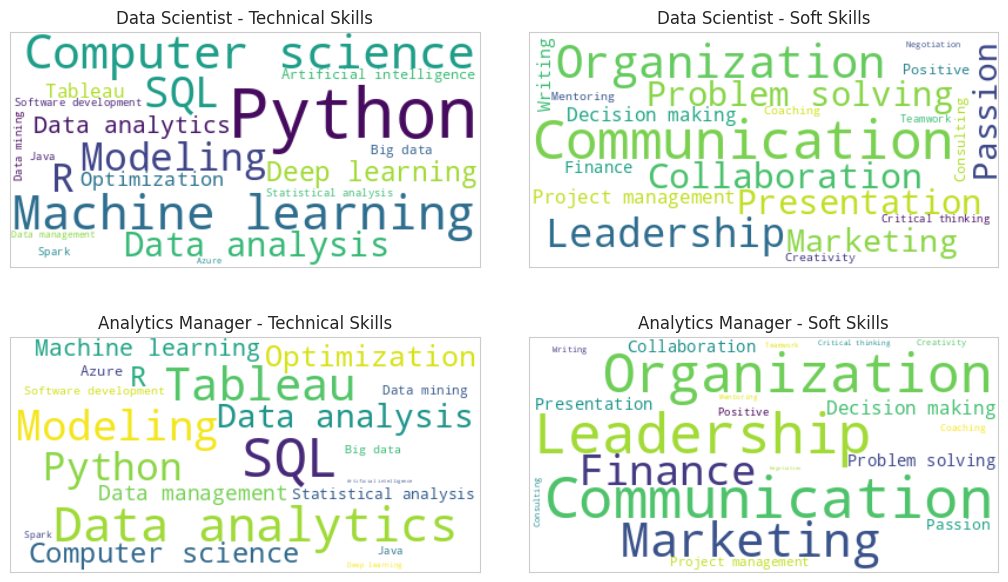

In [ ]:
# Create the word clouds for each job category and skill type:
wc1 = WordCloud(width=400, height=200, background_color='white').generate_from_frequencies(data_scientist_technical_counts)
wc2 = WordCloud(width=400, height=200, background_color='white').generate_from_frequencies(data_scientist_soft_counts)
wc3 = WordCloud(width=400, height=200, background_color='white').generate_from_frequencies(analytics_manager_technical_counts)
wc4 = WordCloud(width=400, height=200, background_color='white').generate_from_frequencies(analytics_manager_soft_counts)

# Create the GridSpec:
fig = plt.figure(figsize=(11, 6))
gs = GridSpec(nrows=2, ncols=2, figure=fig, wspace=0.1, hspace=0.3)

# Add the word clouds to the GridSpec:
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(wc1, interpolation='bilinear')
ax1.set_title('Data Scientist - Technical Skills')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(wc2, interpolation='bilinear')
ax2.set_title('Data Scientist - Soft Skills')

ax3 = fig.add_subplot(gs[1, 0])
ax3.imshow(wc3, interpolation='bilinear')
ax3.set_title('Analytics Manager - Technical Skills')

ax4 = fig.add_subplot(gs[1, 1])
ax4.imshow(wc4, interpolation='bilinear')
ax4.set_title('Analytics Manager - Soft Skills')

# Add lines between and around the word clouds:
for ax in [ax1, ax2]:
    ax.spines['right'].set_visible(True)
for ax in [ax1, ax3]:
    ax.spines['bottom'].set_visible(True)
for ax in [ax2, ax4]:
    ax.spines['left'].set_visible(True)
for ax in [ax3, ax4]:
    ax.spines['top'].set_visible(True)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.1, hspace=0.3)

# Remove the ticks and show the plot:
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

### Feature encoding:

In [ ]:
# Final lists of skills:
technical_skills = [
    "Artificial intelligence", "Azure", "Big data", "Computer science",
    "Data analysis", "Data analytics", "Data management", "Data mining",
    "Deep learning", "Java", "Machine learning", "Modeling", "Optimization",
    "Python", "R", "Software development", "SQL", "Spark",
    "Statistical analysis", "Tableau"
]

soft_skills = [
    "Collaboration", "Communication", "Consulting", "Creativity",
    "Critical thinking", "Decision making", "Finance", "Leadership",
    "Marketing", "Negotiation", "Organization", "Passion", "Positive",
    "Presentation", "Problem solving", "Project management", "Teamwork",
    "Writing", "Coaching", "Mentoring"
]

skills = technical_skills + soft_skills

In [ ]:
# Create a new list of skills:
skills_list = [skill.lower() for skill in skills]

# Create a new column with the one hot encoded skills:
mlb = MultiLabelBinarizer(classes=skills_list)
df_encoded = df.join(pd.DataFrame(mlb.fit_transform(df['Descriptions'].str.findall('|'.join(skills_list))), columns=skills, index=df.index))
df_encoded = df_encoded.drop(columns=["Title", "Company", "Location", "Rating", "Date", "Salary", "Descriptions"]).astype("int8")

In [ ]:
df_encoded.head()

,Artificial intelligence,Azure,Big data,Computer science,Data analysis,Data analytics,Data management,Data mining,Deep learning,Java,...,Organization,Passion,Positive,Presentation,Problem solving,Project management,Teamwork,Writing,Coaching,Mentoring
0,1,0,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,1,0,0,0,0,0,...,1,1,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## 5. Curriculum design with hierarchical clustering:

We Implement hierarchical clustering algorithm
- We generate a distance matrix to describe the relationships between skills.
- We develop a course curriculum based on the clustering results (8–12 courses with at least 3 skills/topics covered in each).

### Hierarchical clustering implementation:

We applied the hierarchical clustering algorithm to the one-hot encoded dataframe using two distance metrics: cosine similarity and Euclidean distance. Cosine similarity is particularly useful for data where direction is important, as is the case with one-hot encoded dataframes. In our study, the distance matrix generated by the cosine similarity approach produced a more effective dendrogram. As a result, the course curriculum was developed based on the dendrogram generated by the cosine similarity approach.

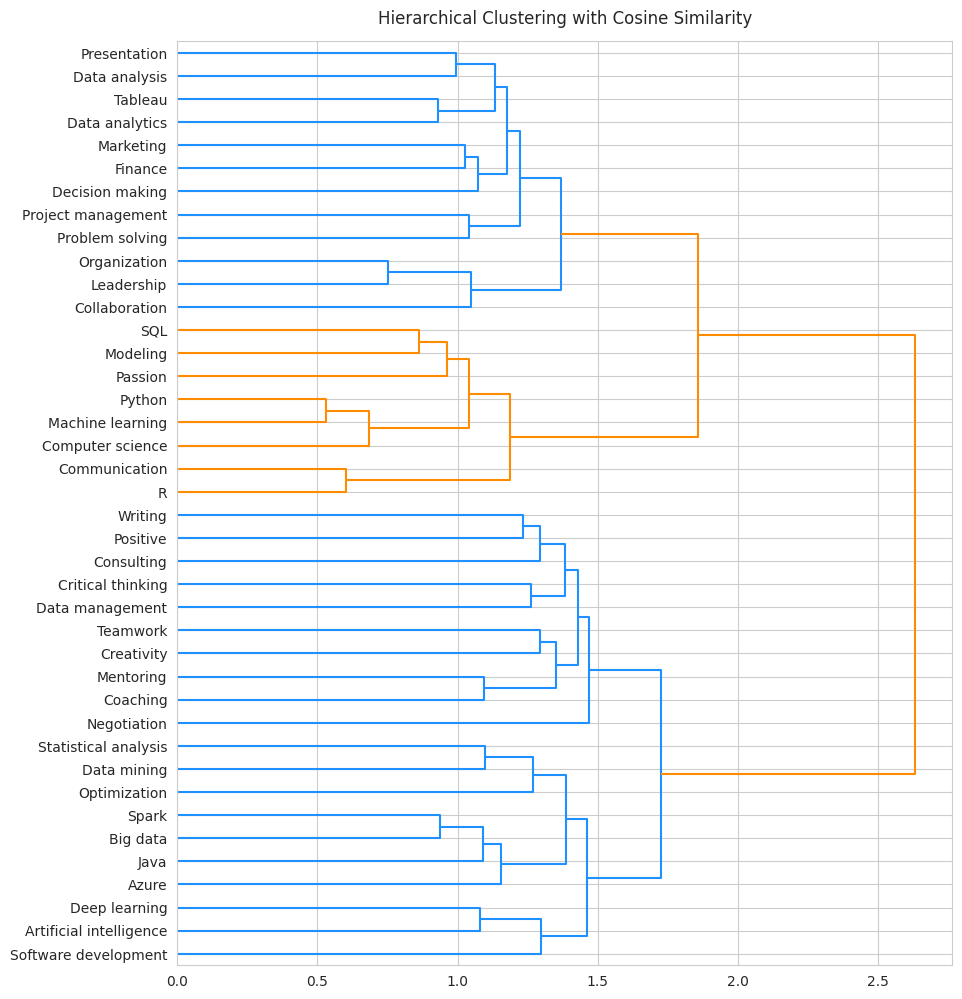

In [ ]:
# Compute the distance matrix:
dist = 1 - cosine_similarity(df_encoded.T)

# Compute the linkage matrix using complete linkage:
linkage_matrix = sch.linkage(dist, method='complete')

# Create the figure and set the facecolor to white:
fig = plt.figure(facecolor='white', figsize=(10, 12))

# Plot the dendrogram:
dendrogram = sch.dendrogram(linkage_matrix, labels=df_encoded.columns, leaf_rotation=0, orientation='right', leaf_font_size=10)

# Set the title of the plot:
plt.title('Hierarchical Clustering with Cosine Similarity', y=1.01)

# Show the plot:
plt.show()

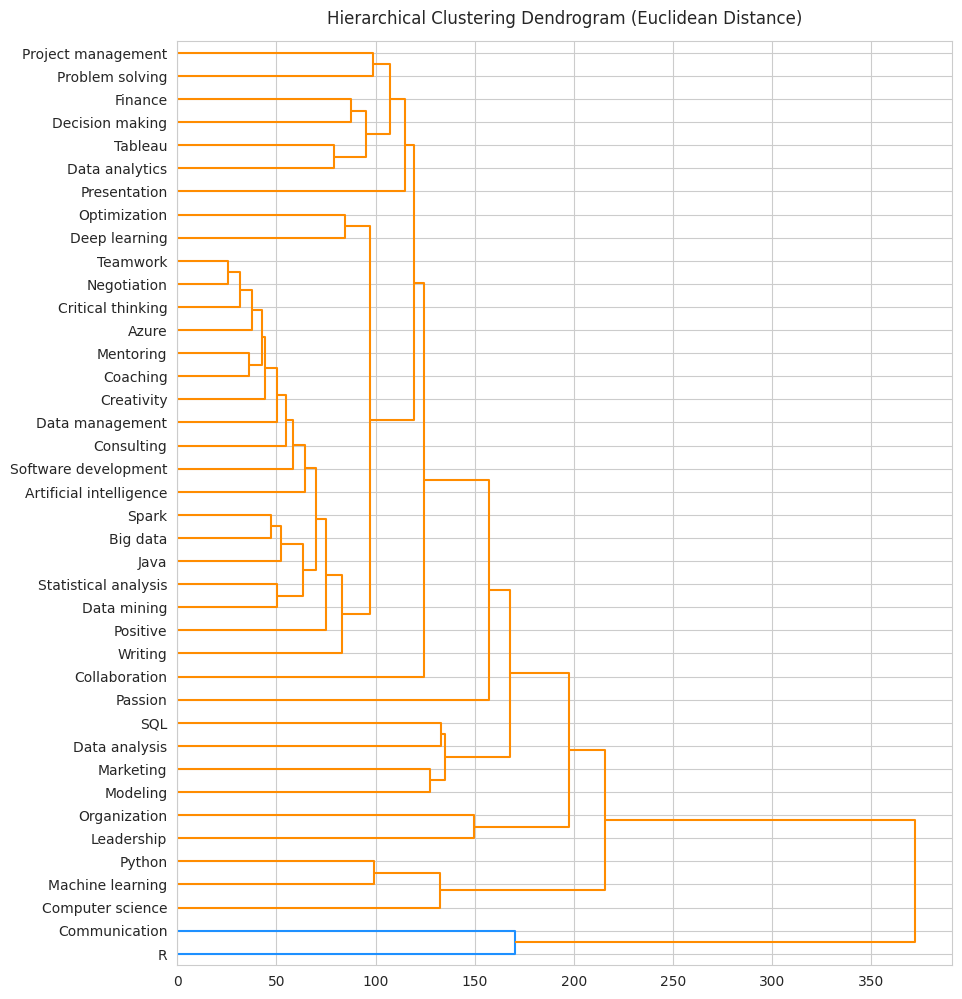

In [ ]:
# Compute the Euclidean distance between each pair of one-hot encoded job skills:
normalized_rows = normalize(np.asarray(df_encoded), axis=1)
D = np.abs(normalized_rows[:, :, np.newaxis] - normalized_rows[:, np.newaxis, :]).sum(axis=0)

# Convert the distance matrix to a condensed distance matrix:
condensed_D = sch.distance.squareform(D)
linkage_matrix = sch.linkage(condensed_D, method='complete', metric='euclidean')

# Create the figure and set the facecolor to white:
fig = plt.figure(facecolor='white', figsize=(10, 12))

# Plot the dendrogram:
dendrogram = sch.dendrogram(linkage_matrix, labels=df_encoded.columns, leaf_rotation=0, orientation='right', leaf_font_size=10)

# Set the title of the plot:
plt.title('Hierarchical Clustering Dendrogram (Euclidean Distance)', y=1.01)

# Show the plot:
plt.show()

### Proposed course curriculum:

Based on the hierarchical clustering results, we have designed a comprehensive course curriculum, which covers at least 3 skills/topics in each course. Our analysis has resulted in the identification of 10 courses, as outlined below:
1. Introduction to Data Analysis and Analytics: The course will cover the fundamentals of data analysis and analytics, with a focus on practical tools and techniques such as Tableau for effective decision making in various industries. Additionally, the course will include instruction on how to create visually compelling and informative presentations of data analysis results.
2. Strategic Business Management: This course provides students with a comprehensive understanding of the interconnectedness of marketing, finance, and decision making in the context of strategic business management. Students will learn how to analyze market trends, develop financial strategies, and make informed decisions that support the long-term success of the organization.
3. Machine Learning for Data Science: This course is designed to provide students with a comprehensive introduction to machine learning and computer science using Python. Students will learn how to use popular machine learning libraries, such as scikit-learn and TensorFlow, to develop predictive models for real-world applications.
4. Leading and Collaborating for Effective Organizations: This course is designed to provide students with a comprehensive understanding of the principles and practices of organization, leadership, and collaboration. Students will learn how to create and manage effective teams, develop leadership skills, and foster a culture of collaboration and innovation in organizations.
5. SQL Data Modeling - From Theory to Passion: This course is designed to provide students with a comprehensive understanding of SQL data modeling and its applications. Students will learn how to design, implement, and manage databases using SQL, and develop a passion for data modeling as a tool for solving complex business problems.
6. Critical Thinking for Data-Driven Management: This course is designed to provide students with a comprehensive understanding of the role of critical thinking in data-driven consulting and effective data management. Students will learn how to analyze complex data sets, develop insights, and make informed decisions that support organizational goals.
7. Team Building and Creative Leadership: This course is designed to provide students with a comprehensive understanding of the principles and practices of team building, creative leadership, mentoring, and coaching. Students will learn how to build and manage effective teams, develop creativity and innovation, and provide guidance and support to team members to foster their professional growth and development.
8. Data Analytics and Optimization: This course is designed to provide students with a comprehensive understanding of statistical analysis, data mining, and optimization techniques for data analytics. Students will learn how to analyze complex data sets and identify patterns and relationships to support organizational goals.
9. Big Data Processing with Spark and Java: This course is designed to provide students with a comprehensive understanding of big data processing using Spark and Java. Students will learn how to design and implement big data processing pipelines, optimize data processing performance, and work with large-scale data sets.
10. AI Applications in Software Development: This course is designed to provide students with a comprehensive understanding of deep learning and artificial intelligence (AI) applications in software development. Students will learn how to design and implement deep learning models, integrate AI techniques into software applications, and develop intelligent systems for real-world problems.

## 6. Curriculum design with k-means clustering or DBSCAN:

We Implement k-means clustering algorithm or DBSCAN clustering algorithm:
- We engineer 10 unique features to describe each skill for clustering (e.g., skill frequency, average salary for the skill, binary indication of a soft or hard skill, etc.). The distance matrix used in Section 3 may be incorporated but counts as only one feature.
- We develop a course curriculum based on the clustering results (8–12 courses with at least 3 skills/topics covered in each).

We also use the elbow method to determine the optimal number of clusters, k, for k-means clustering or the optimal eps value when using DBSCAN clustering.

### Feature engineering:

You may be wondering why we need to perform feature engineering again. The distance matrix generated previously in section 5 is not sufficient. Before applying k-means or DBSCAN algorithms, we need to engineer nine additional features, bringing the total to ten. To clarify the process, we've provided a step-by-step guide below that outlines how these features are obtained.

Distance matrix used in section 5:

The distance matrix obtained in section 5 is allowed to be used as only one feature. We explored two distance metrics, namely Euclidean and cosine similarity, and found that the cosine similarity matrix resulted in better clustering. Therefore, we used the cosine similarity matrix as a feature in our subsequent analyses.

In [ ]:
dist_df = pd.DataFrame(dist, index=df_encoded.columns)

Average education level for skill:

We have previously demonstrated, using `CountVectorizer`, that the terms "master degree" and "bachelor degree" frequently appear in job descriptions, with "bachelor degree" being nearly twice as common. To capture the relationship between the skills required for jobs in the market and educational level, we can engineer a new feature by counting the occurrences of skills in job postings that require a master's degree. This enables us to differentiate between graduate studies and other levels of education. It should be noted that job postings that require a Ph.D. degree are very rare.

In [ ]:
df_skills = df.copy()
df_skills["Education"] = df_skills["Descriptions"].str.contains("(?i)master degree").astype(int)
# Find average education level for skills:
df_skills['Skills'] = df_skills['Descriptions'].apply(lambda x:[skill for skill in skills if skill.lower() in x.lower()])
df_skills = df_skills.explode('Skills')
skill_education = df_skills.groupby('Skills')['Education'].mean().sort_values(ascending=False)

Average organization level for skill:

We have yet to incorporate the 'Title' column in the dataframe. Certain skills may be more applicable to managerial or senior roles, while others may be more relevant to non-management positions. To account for this, we can engineer a feature that reflects how frequently a particular skill is required in a managerial or senior role, which typically involve higher levels of organizational responsibility.

In [ ]:
df_skills = df.copy()
df_skills["Level"] = df_skills["Title"].str.contains("(?i)senior|manager|mng").astype(int)
# Find average level for skills:
df_skills['Skills'] = df_skills['Descriptions'].apply(lambda x:[skill for skill in skills if skill.lower() in x.lower()])
df_skills = df_skills.explode('Skills')
skill_level = df_skills.groupby('Skills')['Level'].mean().sort_values(ascending=False)

Binary indication of skills:

Another straightforward feature is the binary indication of skills, which is a value of 0 if the skill is considered technical and a value of 1 if the skill is classified as soft. This feature can be easily derived from the existing classification of skills in the dataset.

In [ ]:
skill_binary = pd.Series([0 if skill in technical_skills else 1 for skill in skills], name="Binary", index=skills)

Skill frequency:

Skill frequency is one of the most straightforward features to engineer. It can be obtained by simply counting the number of times a particular skill is mentioned in the job description. This feature can provide a quick overview of the most in-demand skills.

In [ ]:
skill_counts = pd.Series(dtype="float64", name="Frequency")

# Loop through each keyword and count its frequency of appearance in the 'Descriptions' column:
for keyword in skills:
    # Count the appearances of the keyword in the 'Descriptions' column and add it to the common name's count:
    count = df["Descriptions"].str.contains(f'(?i)\\b{keyword}\\b', regex=True, case=False).sum()
    # Check if count is not zero:
    if count != 0:
        skill_counts.loc[keyword] = count

Average salary for skill:

The 'Salary' column in our dataset provides the annual salary for each job posting. We can engineer a new feature: the average salary associated with a particular skill. This feature takes into account the fact that a skill may appear in multiple job postings with varying salaries. By calculating the arithmetic mean of all salaries associated with a particular skill, we can obtain a more accurate representation of the market value of that skill.

In [ ]:
# Find average salary for skills:
df_skills = df.dropna(subset=["Salary"]).copy()
df_skills['Skills'] = df_skills['Descriptions'].apply(lambda x:[skill for skill in skills if skill.lower() in x.lower()])
df_skills = df_skills.explode('Skills')
skill_salary = df_skills.groupby('Skills')['Salary'].mean().sort_values(ascending=False)

Average posting date for skill:

Another important feature that is often overlooked is the time relevance of a skill. Skills that appear frequently in older job postings may be outdated or less important than those that frequently appear in more recent postings. The 'Date' column in the dataframe contains the number of days since each job was posted. By calculating the average date associated with each skill across multiple job postings, we can obtain a more accurate representation of its current value in the job market.

In [ ]:
# Find average date for skills:
df_skills = df.dropna(subset=["Date"]).copy()
df_skills['Skills'] = df_skills['Descriptions'].apply(lambda x:[skill for skill in skills if skill.lower() in x.lower()])
df_skills = df_skills.explode('Skills')
skill_date = df_skills.groupby('Skills')['Date'].mean().sort_values(ascending=False)

Average rating for skill:

The 'Rating' column in our job postings dataframe provides valuable information about the perceived value of each job posting. We can leverage this information to engineer a new feature that rates each skill based on its importance for higher-rated jobs. Since a skill may appear in multiple job postings with varying ratings, we can calculate the average rating associated with each skill to obtain a more accurate representation of its value.

In [ ]:
# Find average rating for skills:
df_skills = df.dropna(subset=["Rating"]).copy()
df_skills['Rating'] = pd.to_numeric(df_skills['Rating'], errors='coerce')
df_skills['Skills'] = df_skills['Descriptions'].apply(lambda x:[skill for skill in skills if skill.lower() in x.lower()])
df_skills = df_skills.explode('Skills')
skill_rating = df_skills.groupby('Skills')['Rating'].mean().sort_values(ascending=False)

Location indicator for skills:

Additionally, some skills may be more relevant to remote job positions. To capture this, a new feature was engineered by counting the number of job postings that indicated the position was "Remote" for each skill.

In [ ]:
df_skills = df.copy()
df_skills["Remote"] = df_skills["Location"].str.contains("(?i)Remote").astype(int)
# Find average level for skills:
df_skills['Skills'] = df_skills['Descriptions'].apply(lambda x:[skill for skill in skills if skill.lower() in x.lower()])
df_skills = df_skills.explode('Skills')
skill_remote = df_skills.groupby('Skills')['Remote'].mean().sort_values(ascending=False)

Number of unique companies for skills:

We created a more sophisticated feature that captures the frequency of a skill being demanded by multiple companies. Recognizing that some job postings are exclusive to a single company, we assigned higher importance to skills that are demanded by a greater number of unique companies. To calculate this, we counted the number of unique companies demanding each skill.

In [ ]:
# Find number of unique companies for each skills:
df_skills = df.copy()
df_skills["Skills"] = df_skills['Descriptions'].apply(lambda x:[skill for skill in skills if skill.lower() in x.lower()])
df_skills = df_skills.explode("Skills")
skill_company = df_skills.groupby("Skills", as_index=False)["Company"].nunique().set_index("Skills")["Company"]

### Final features:

The following table displays all the features except for the distance matrix, which will be concatenated later. It is important to note that all values need to be normalized using a scaler. In this case, the `MinMaxScaler` is the appropriate scaler for normalization. Note that, the cosine similarity matrix does not require scaling as it is already normalized.

In [ ]:
# Concatenate series into a DataFrame:
df_features = pd.concat([skill_company, skill_remote, skill_rating, skill_date, skill_salary,
                         skill_counts, skill_binary, skill_level, skill_education], axis=1)

# Normalize the columns in 'df_Kmeans':
scaler = MinMaxScaler()
df_features = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns, index=df_features.index)
df_features.head()

,Company,Remote,Rating,Date,Salary,Frequency,Binary,Level,Education
Artificial intelligence,0.115983,0.244428,0.932985,0.493913,0.360730,0.172471,0.0,0.000000,0.567462
Azure,0.053748,0.622901,0.365687,0.777475,0.527130,0.074627,0.0,0.432501,0.856140
Big data,0.103253,0.076190,0.172932,1.000000,0.759065,0.149254,0.0,0.286808,0.595627
Coaching,0.049505,0.753348,0.000000,0.369989,0.438278,0.077944,1.0,0.907695,0.380439
Collaboration,0.267327,0.809289,0.738802,0.336632,0.371704,0.391376,1.0,0.642805,0.551151


In [ ]:
# Concatenate 'df_Kmeans' and 'dist_matrix' into a DataFrame:
df_features = pd.concat([df_features, dist_df], axis=1)
df_features.columns = df_features.columns.astype(str)

### k-means Clustering Implementation

After engineering the features, we need to determine the optimal number of clusters for k-means clustering. We used the elbow method for this purpose, where we plotted the inertia and distortion of the clusters against the number of clusters. We also attempted to use DBSCAN, but it was not effective in our case. The elbow plots for both inertia and distortion show a sudden decrease at `n_clusters = 9`. Therefore, we decided to use nine clusters for the final implementation of k-means clustering.

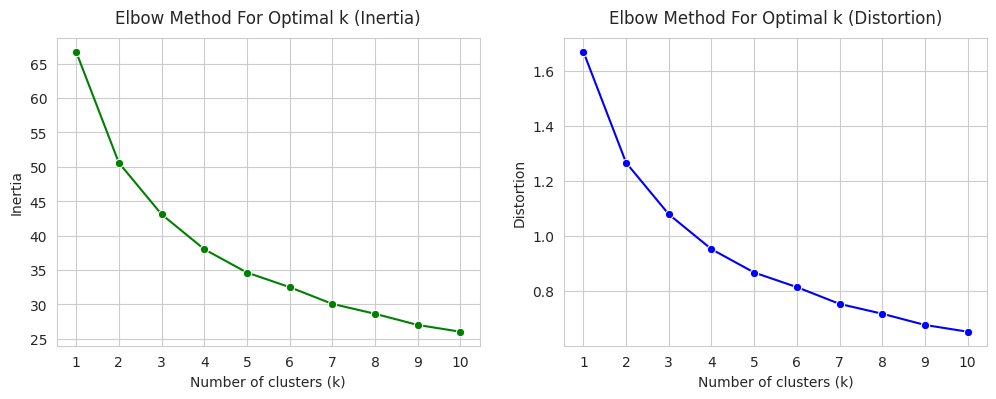

In [ ]:
# Fit KMeans with different k values:
inertias = []
distortions = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(df_features)
    inertias.append(kmeans.inertia_)
    distortions.append(kmeans.inertia_ / df_features.shape[0])

# Set up the subplots:
fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

# Plot the inertia elbow:
sns.lineplot(x=k_range, y=inertias, ax=axs[0], color='green', marker='o')
axs[0].set_xlabel('Number of clusters (k)')
axs[0].set_ylabel('Inertia')
axs[0].set_xticks(range(1, 11, 1))
axs[0].set_title('Elbow Method For Optimal k (Inertia)', y=1.02)

# Plot the distortion elbow:
sns.lineplot(x=k_range, y=distortions, ax=axs[1], color='blue', marker='o')
axs[1].set_xlabel('Number of clusters (k)')
axs[1].set_ylabel('Distortion')
axs[1].set_xticks(range(1, 11, 1))
axs[1].set_title('Elbow Method For Optimal k (Distortion)', y=1.02)

# Display the plot:
plt.subplots_adjust(wspace=0.2)
plt.show()

Another important note is that the `KMeans` algorithm is highly sensitive to initialization. To mitigate this issue, we used the `k-means++` initialization method. However, even with `k-means++`, the resulting clusters may vary depending on the value of `random_state`. To obtain stable results, we experimented with different values of `random_state` and ultimately selected the one that produced nine clusters, which we deemed appropriate for our analysis of the course curriculum.

In [ ]:
# Use number of clusters obtained from elbow method:
n_clusters = 9

# perform k-means clustering on the normalized data:
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=41, n_init=10, max_iter=1000)
kmeans.fit_predict(df_features)

# Add cluster labels as a new column to the original dataframe:
df_Kmeans = pd.DataFrame(columns=['cluster'], index=df_features.index)

# Get the cluster assignments for each data point:
labels = kmeans.labels_
df_Kmeans['cluster'] = labels

# Reset the index of the dataframe to convert the skills index to a regular column:
df_Kmeans = df_Kmeans.reset_index()

# Group the dataframe by cluster label and aggregate the skills into lists:
clustered_skills = df_Kmeans.groupby('cluster')['index'].agg(list)
cluster_lengths = clustered_skills.apply(lambda x: len(x))

# Convert the Series object to a DataFrame:
df_clustered_skills = pd.DataFrame({'Cluster': clustered_skills.index, 'Skills': clustered_skills.values})

# View the resulting dataframe:
df_clustered_skills['Cluster'] += 1
df_clustered_skills['Skills'] = df_clustered_skills['Skills'].apply(lambda x: ', '.join(x))
print(df_clustered_skills.to_markdown(index=False, tablefmt='fancy_grid'))

╒═══════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│   Cluster │ Skills                                                                                                   │
╞═══════════╪══════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│         1 │ Data analysis, Data analytics, Data management, Data mining, Optimization, Statistical analysis, Tableau │
├───────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│         2 │ Collaboration, Decision making, Finance, Marketing, Presentation, Problem solving                        │
├───────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│         3 │ Computer science, Machine learning, Modeling, Python, R, SQL                                             │
├───────────┼───────────────────

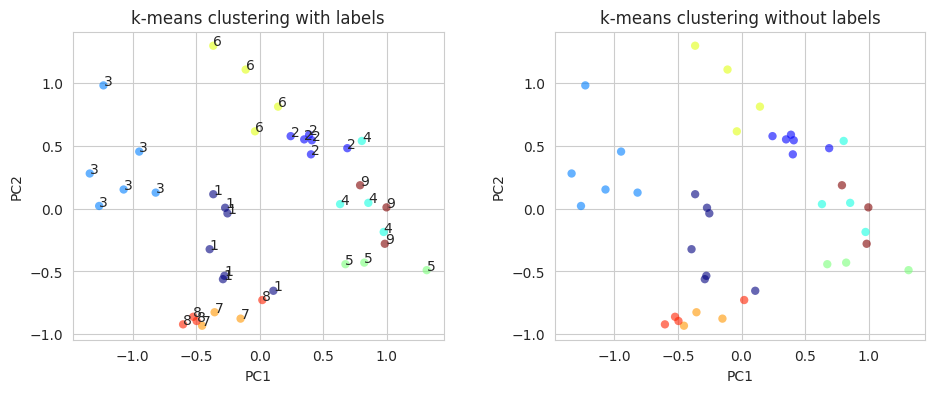

In [ ]:
# Get the first two principal components of the feature data:
pca = PCA(n_components=2)
features_2d = pca.fit_transform(df_features)

# Add 1 to the labels array to make the cluster numbers start from 1:
labels_shifted = labels + 1
kwargs = dict(cmap=plt.get_cmap('jet', n_clusters), edgecolor='none', alpha=0.6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Plot with labels:
ax1.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, **kwargs)
for i, label in enumerate(labels+1):
    ax1.text(features_2d[i, 0], features_2d[i, 1], str(label))
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('k-means clustering with labels')

# Plot without labels:
ax2.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, **kwargs)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('k-means clustering without labels')

# Show the plot:
plt.subplots_adjust(wspace=0.3)
plt.show()

### Proposed course curriculum:

Based on the k-means clustering results, we have designed a comprehensive course curriculum, which covers at least 3 skills/topics in each course. In this case we could identify 8 courses, as outlined below:
1. Advanced Skills for Project Management: This course is designed to develop effective communication and leadership skills through a combination of coaching, consulting, critical thinking, positive mindset, and project management. Students will learn how to communicate and lead effectively in various professional settings. The course will provide students with practical tools and strategies for building strong relationships, managing projects, and leading teams towards success. Students will also learn how to write effectively for different audiences, including reports, proposals, and presentations.
2. Data Analytics and Visualization: This course is designed to provide students with a strong foundation in data analysis, data analytics, modeling, optimization, and data visualization using Tableau. Students will learn how to collect, analyze, and interpret data using statistical methods and tools. You will also gain practical skills in data modeling and optimization to solve real-world problems. In addition, students will learn how to create compelling visualizations using Tableau.
3. Advanced Topics in Artificial Intelligence: This course covers advanced topics in artificial intelligence and big data, including deep learning, big data processing using Spark, and programming in Java. Through hands-on projects and case studies, students will gain practical experience in implementing and deploying AI and big data solutions.
4. Business Strategy and Problem-Solving: This course is designed to equip students with the necessary skills to develop effective business strategies and make data-driven decisions. Students will learn how to collaborate with team members, communicate ideas and strategies effectively, and solve complex problems using critical thinking and analytical tools. In addition, students will learn about financial analysis and marketing strategies.
5. Soft Skills for Effective Teamwork : In this course, students will learn the essential soft skills necessary for effective collaboration and leadership. Students will gain expertise in areas such as creativity, mentoring, negotiation, and teamwork, which are essential for building successful teams and leading them towards achieving their goals.
6. Leadership and Communication in the Workplace: This course is designed to help students develop effective leadership and communication skills in the workplace. Students will learn how to effectively communicate with team members and how to organize and prioritize tasks. The course will cover topics such as active listening, conflict resolution, and public speaking. Students will also explore strategies for building and managing teams, motivating team members, and achieving organizational goals.
7. Foundations of Data Science: This course provides an introduction to the fundamental concepts and techniques of data science. Students will learn about data management, data mining, and statistical analysis.
8. Applied Data Science and Machine Learning: This course provides a comprehensive introduction to applied data science using machine learning algorithms and programming languages such as Python, R, and SQL. Students will learn how to analyze, clean, and preprocess large datasets, as well as how to build predictive models and evaluate their performance.

## Curriculum design with ChatGPT:

We can further implement OpenAI’s API to describe the clustering results (e.g.,, asking ChatGPT to describe what is common amongst the clusters). For ChatGPT API, use gpt-3.5-turbo or newer model (newer model may be available).

In [ ]:
# Initialize 'Console' and get terminal width:
console = Console(width=shutil.get_terminal_size().columns)

### Describing k-means clusters:

We can use OpenAI's GPT-3 model to generate a description of what's common within each cluster. By passing a prompt to the model, we can ask it to describe the similarities among the data points in each cluster. This way, we can gain insights into the patterns and trends present within our dataset.

In [ ]:
try:
    for cluster_id in range(n_clusters):
        # Get the data points belonging to the current cluster:
        cluster_data = df_clustered_skills.loc[cluster_id]["Skills"]

        # Generate a description for the cluster using OpenAI's GPT-3 model:
        prompt = f"""
        Please describe what is common amongst cluster {cluster_id+1} data points.\n
        The data points in cluster {cluster_id+1} are: {cluster_data}.
        """

        response = openai.Completion.create(
            engine="text-davinci-002",
            prompt=prompt,
            max_tokens=1024,
            n=1,
            stop=None,
            temperature=0.5,
        )

        # Print the description:
        description = response.choices[0].text.strip()
        console.print(f"Cluster {cluster_id+1}: {description}")
except:
    console.print("OpenAI not responding.")

Cluster 1: The commonalities among the data points in cluster 1 are that they 
are all related to professional skills. Coaching and consulting are both forms 
of professional advice-giving, while critical thinking and project management 
are both important skills for leading and organizing teams. Writing is also an 
important skill for many professional fields.

Cluster 2: The commonalities between these data points are that they are all 
methods of data analysis.

Cluster 3: The commonality amongst these data points is that they are all 
technologies used in data science.

Cluster 4: The commonalities amongst cluster 4 data points are:
        - The ability to work well with others (Collaboration)
        - The ability to make decisions (Decision making)
        - The ability to understand and manage finances (Finance)
        - The ability to market and sell products or services (Marketing)
        - Having a strong interest or feeling for something (Passion)
        - The ability to communicate effectively (Presentation)
        - The ability to find solutions to problems (Problem solving)

Cluster 5: One thing that is common amongst these data points is that they are 
both related to the cloud. Azure is a cloud computing platform and software 
development is often done in the cloud.

Cluster 6: The most common thing among these data points is that they are all 
skills that are necessary for success in a team environment. Creativity is 
important for coming up with new ideas, mentoring is important for helping 
others to develop their skills, and negotiation is important for resolving 
conflicts.

Cluster 7: Commonalities:
        - All three skills are important for managing a team or project.
        - All three skills involve working with other people.
        - All three skills involve some level of coordination.

Cluster 8: All of the data points in cluster 8 are related to data. Data 
management deals with organizing and storing data. Data mining is the process of
extracting valuable information from data. Statistical analysis is the process 
of using statistical methods to analyze data.

Cluster 9: The commonalities between these data points are that they are all 
related to programming and data analysis.

If we attempt to describe what's common across all clusters in one prompt, it could become too long and the response from GPT-3 may not be optimal. Despite the potential limitations, we have included the solution for describing what's common across all clusters below:

In [ ]:
try:
    # Generate a description for the cluster using OpenAI's GPT-3 model:
    prompt = f"""
    Please describe what is common amongst clusters 1 to {n_clusters}, as follows:
    """
    for cluster_id in range(n_clusters):
        cluster_data = df_clustered_skills.loc[cluster_id]["Skills"]
        prompt += f"Cluster {cluster_id+1}: {cluster_data}\n"

    response = openai.Completion.create(
        engine="text-davinci-002",
        prompt=prompt,
        max_tokens=1024,
        n=1,
        stop=None,
        temperature=0.5,
    )

    # Print the description:
    description = response.choices[0].text.strip()
    console.print(f"Response: {description}")
except:
    console.print("OpenAI not responding.")

Response: The clusters 1 to 9 share the following commonalities:
- Data analysis
- Data analytics
- Modeling
- Optimization
- Tableau
- Artificial intelligence
- Big data
- Deep learning
- Java
- Spark
- Collaboration
- Decision making
- Finance
- Marketing
- Passion
- Presentation
- Problem solving
- Azure
- Software development
- Creativity
- Mentoring
- Negotiation
- Teamwork
- Communication
- Leadership
- Organization
- Data management
- Data mining
- Statistical analysis
- Computer science
- Machine learning
- Python
- R
- SQL

### Designing a curriculum:

Remarkably, we can even utilize the GPT-3 model to design our course curriculum. We can generate a prompt to request a proposed course outline, either by attempting to generate the entire curriculum in one prompt or by using a for loop to obtain more precise responses.

In [ ]:
try:
    i = 1
    for cluster_id in range(n_clusters):
        # Get the data points belonging to the current cluster:
        cluster_data = df_clustered_skills.loc[cluster_id]["Skills"]
        if cluster_lengths.iloc[cluster_id] < 3:
            continue

        # Generate a description for the cluster using OpenAI's GPT-3 model:
        prompt = f"""
        Please suggest a title and a brief description for Course {i}, which will cover the following
        skills in Cluster {i}: {cluster_data}.
        """

        response = openai.Completion.create(
            engine="text-davinci-002",
            prompt=prompt,
            max_tokens=1024,
            n=1,
            stop=None,
            temperature=0.5,
        )

        # Print the description:
        description = response.choices[0].text.strip()
        console.print(f"{description}")
        i += 1
except:
    console.print("OpenAI not responding.")

Course 1: Introduction to Coaching, Consulting, and Critical Thinking

This course will introduce students to the basic concepts and skills of 
coaching, consulting, and critical thinking. Students will learn how to apply 
these skills to real-world situations and will be given opportunities to 
practice these skills through group exercises and projects.

Course 2: Data Analytics and Modeling
        
        This course will cover the skills of data analysis, data analytics, 
modeling, and optimization. Students will learn how to use various software 
programs to analyze data, create models, and optimize results. Tableau will be 
used extensively to visualize data and results.

Course 3: Artificial Intelligence, Big Data, and Deep Learning

This course will cover the basics of artificial intelligence, big data, and deep
learning. Students will learn about the different types of data, how to process 
and analyze it, and how to build models that can learn from data. The course 
will also cover the basics of Java and Spark, two popular tools for working with
data.

Course 4: Developing Your Business Skills

This course will cover important business skills such as collaboration, decision
making, finance, marketing, passion, presentation, and problem solving. These 
skills are essential for anyone looking to start or grow their own business. 
This course will give you the tools you need to be successful in the business 
world.

Course 5: Creative Mentoring for Negotiation and Teamwork

This course will cover the skills of creativity, mentoring, negotiation, and 
teamwork. Students will learn how to be creative in their approach to problem 
solving, how to mentor others in a way that leads to productive outcomes, and 
how to negotiate and work effectively in teams.

Course 6: Effective Communication, Leadership, and Organization Skills

This course will cover the essential skills of communication, leadership, and 
organization. Students will learn how to effectively communicate with others, 
how to lead and motivate a team, and how to effectively organize their time and 
resources. This course will be beneficial for students who wish to improve their
communication, leadership, and organizational skills.

Course 7: Data Management, Data Mining, and Statistical Analysis

This course will cover the essential skills of data management, data mining, and
statistical analysis. Students will learn how to effectively organize and 
manipulate data, how to mine data for valuable insights, and how to use 
statistical techniques to analyze data. This course will be essential for 
students who want to pursue careers in data science, business analytics, or any 
field that relies heavily on data.

Course 8: Introduction to Data Science

This course will cover the basics of data science, including computer science, 
machine learning, Python, R, and SQL. Students will learn how to collect, clean,
and analyze data, as well as how to build models and algorithms to make 
predictions.

In [ ]:
try:
    n_courses = len(cluster_lengths[cluster_lengths >= 3])

    # Generate a description for the cluster using OpenAI's GPT-3 model:
    prompt = f"""
    Using format Course #: Descriptions, please suggest a title and a description for Courses 1 to {n_courses},
    which will cover the skills in Clusters 1 to {n_courses}.
    """
    i = 1
    for cluster_id in range(n_clusters):
        if cluster_lengths.iloc[cluster_id] < 3:
            continue
        cluster_data = df_clustered_skills.loc[cluster_id]["Skills"]
        prompt += f"Cluster {i}: {cluster_data}\n"
        i += 1
    prompt

    response = openai.Completion.create(
        engine="text-davinci-002",
        prompt=prompt,
        max_tokens=2048,
        n=1,
        stop=None,
        temperature=0.5,
    )

    # Print the description:
    description = response.choices[0].text.strip()
    console.print(f"{description}")
except:
    console.print("OpenAI not responding.")

Course 1: Introduction to Coaching
Description:

This course will introduce students to the basics of coaching, including its 
history, key concepts and techniques. Students will learn how to use coaching to
improve their own performance and that of others, and will explore the different
approaches to coaching.

Course 2: Introduction to Consulting
Description:

This course will introduce students to the basics of consulting, including its 
history, key concepts and techniques. Students will learn how to use consulting 
to improve their own performance and that of others, and will explore the 
different approaches to consulting.

Course 3: Introduction to Critical Thinking
Description:

This course will introduce students to the basics of critical thinking, 
including its history, key concepts and techniques. Students will learn how to 
use critical thinking to improve their own performance and that of others, and 
will explore the different approaches to critical thinking.

Course 4: Introduction to Positive Psychology
Description:

This course will introduce students to the basics of positive psychology, 
including its history, key concepts and techniques. Students will learn how to 
use positive psychology to improve their own performance and that of others, and
will explore the different approaches to positive psychology.

Course 5: Introduction to Project Management
Description:

This course will introduce students to the basics of project management, 
including its history, key concepts and techniques. Students will learn how to 
use project management to improve their own performance and that of others, and 
will explore the different approaches to project management.

Course 6: Introduction to Writing
Description:

This course will introduce students to the basics of writing, including its 
history, key concepts and techniques. Students will learn how to use writing to 
improve their own performance and that of others, and will explore the different
approaches to writing.

Course 7: Introduction to Data Analysis
Description:

This course will introduce students to the basics of data analysis, including 
its history, key concepts and techniques. Students will learn how to use data 
analysis to improve their own performance and that of others, and will explore 
the different approaches to data analysis.

Course 8: Introduction to Data Analytics
Description:

This course will introduce students to the basics of data analytics, including 
its history, key concepts and techniques. Students will learn how to use data 
analytics to improve their own performance and that of others, and will explore 
the different approaches to data analytics.